In [19]:
import xarray as xr

# Open the Zarr store
ds = xr.open_zarr('../output_data.zarr', consolidated=True)

print(ds)
print("\nVariables:", list(ds.data_vars))
print("Time steps:", ds.valid_time.values)

<xarray.Dataset> Size: 293MB
Dimensions:            (valid_time: 124, y: 128, x: 128, number: 10)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 992B 2024-10-01 ... 2024-1...
  * y                  (y) int64 1kB 0 1 2 3 4 5 6 ... 122 123 124 125 126 127
  * x                  (x) int64 1kB 0 1 2 3 4 5 6 ... 122 123 124 125 126 127
    latitude           (y, x) float64 131kB dask.array<chunksize=(128, 128), meta=np.ndarray>
    longitude          (y, x) float64 131kB dask.array<chunksize=(128, 128), meta=np.ndarray>
  * number             (number) int64 80B 0 1 2 3 4 5 6 7 8 9
Data variables:
    t2m_cerra_mean     (valid_time, y, x) float32 8MB dask.array<chunksize=(1, 128, 128), meta=np.ndarray>
    t2m_cerra_members  (number, valid_time, y, x) float32 81MB dask.array<chunksize=(10, 1, 128, 128), meta=np.ndarray>
    t2m_cerra_std      (valid_time, y, x) float32 8MB dask.array<chunksize=(1, 128, 128), meta=np.ndarray>
    t2m_era5_mean      (valid_time, y, x) float64 

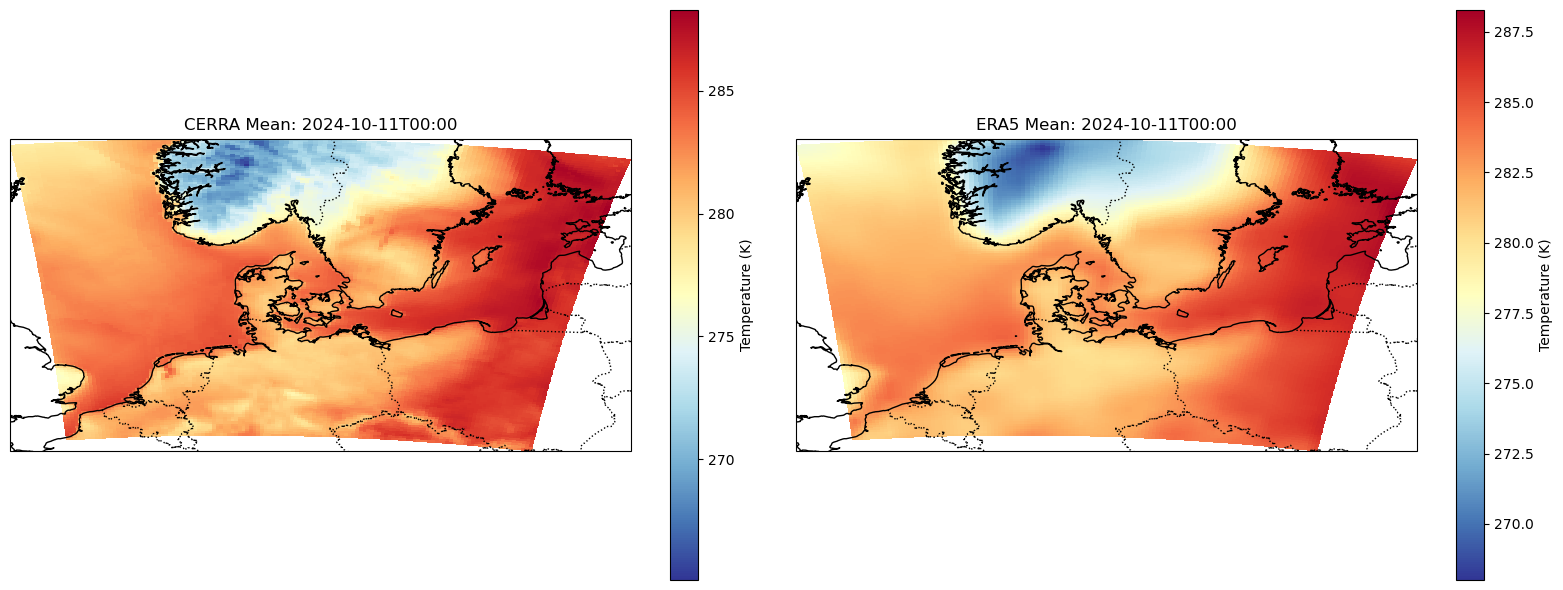

In [20]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Select a specific time index (e.g., the first one)
time_idx = 10
time_str = str(ds.valid_time.isel(valid_time=time_idx).values)[:16]

# Create subplot with projection
fig, ax = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot CERRA Mean
ds['t2m_cerra_mean'].isel(valid_time=time_idx).plot(
    ax=ax[0], 
    x='longitude', y='latitude', 
    transform=ccrs.PlateCarree(), 
    cmap='RdYlBu_r',
    cbar_kwargs={'label': 'Temperature (K)'}
)
ax[0].set_title(f"CERRA Mean: {time_str}")

# Plot ERA5 Mean
ds['t2m_era5_mean'].isel(valid_time=time_idx).plot(
    ax=ax[1], 
    x='longitude', y='latitude', 
    transform=ccrs.PlateCarree(), 
    cmap='RdYlBu_r',
    cbar_kwargs={'label': 'Temperature (K)'}
)
ax[1].set_title(f"ERA5 Mean: {time_str}")

# Add coastlines
for a in ax:
    a.coastlines()
    a.add_feature(cfeature.BORDERS, linestyle=':')

plt.tight_layout()
plt.show()

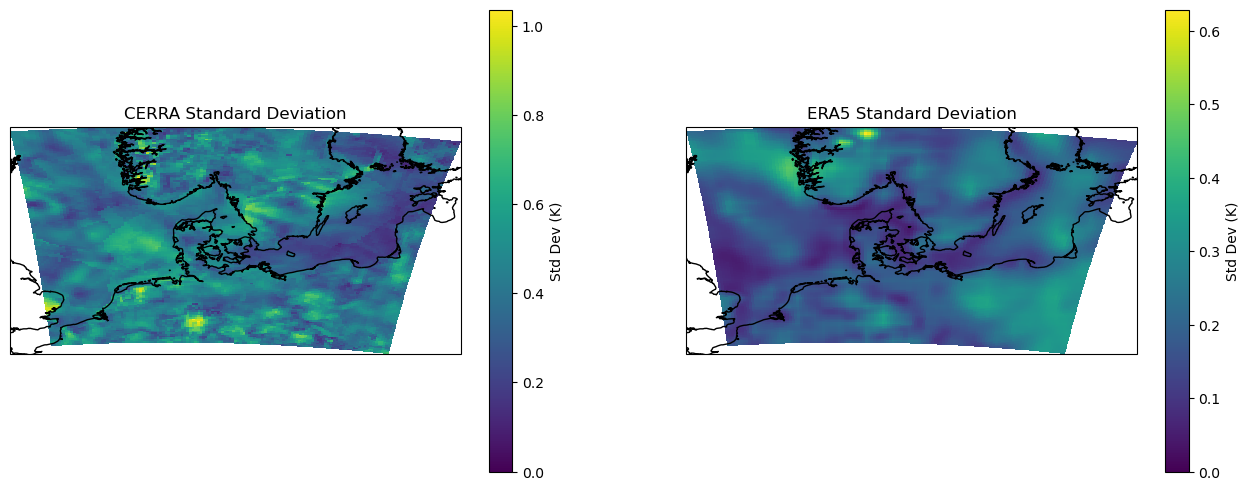

In [21]:
# Select a time index
time_idx = 10  # Arbitrary time step

fig, ax = plt.subplots(1, 2, figsize=(16, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot CERRA Std
ds['t2m_cerra_std'].isel(valid_time=time_idx).plot(
    ax=ax[0], 
    x='longitude', y='latitude', 
    transform=ccrs.PlateCarree(), 
    cmap='viridis',
    vmin=0,
    cbar_kwargs={'label': 'Std Dev (K)'}
)
ax[0].set_title("CERRA Standard Deviation")

# Plot ERA5 Std
ds['t2m_era5_std'].isel(valid_time=time_idx).plot(
    ax=ax[1], 
    x='longitude', y='latitude', 
    transform=ccrs.PlateCarree(), 
    cmap='viridis',
    vmin=0,
    cbar_kwargs={'label': 'Std Dev (K)'}
)
ax[1].set_title("ERA5 Standard Deviation")

for a in ax:
    a.coastlines()

plt.show()